# Análise gráfica dos resultados - Contagem de palavras

Este notebook lê `results/resultados.csv`, calcula estatísticas e gera somente imagens PNG em `images/`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('results')
IMAGES = Path('images')
RESULTS.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)

csv_path = RESULTS / 'resultados.csv'

if not csv_path.exists():
    raise FileNotFoundError(
        'Arquivo results/resultados.csv não encontrado. Execute primeiro no terminal: ./run.sh the'
    )

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

print('Colunas encontradas:', list(df.columns))
print('Quantidade de linhas no CSV original:', len(df))

# Conversão segura dos tipos
df['arquivo'] = df['arquivo'].astype(str)
df['palavra'] = df['palavra'].astype(str)
df['metodo'] = df['metodo'].astype(str)

df['threads'] = (
    df['threads']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['ocorrencias'] = (
    df['ocorrencias']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['tempo_ms'] = (
    df['tempo_ms']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['tamanho_bytes'] = (
    df['tamanho_bytes']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['threads'] = pd.to_numeric(df['threads'], errors='coerce').fillna(0).astype(int)
df['ocorrencias'] = pd.to_numeric(df['ocorrencias'], errors='coerce')
df['tempo_ms'] = pd.to_numeric(df['tempo_ms'], errors='coerce')
df['tamanho_bytes'] = pd.to_numeric(df['tamanho_bytes'], errors='coerce')

df = df.dropna(subset=['tempo_ms', 'ocorrencias', 'tamanho_bytes'])

if df.empty:
    raise ValueError('O DataFrame ficou vazio após a leitura do CSV. Verifique o arquivo results/resultados.csv.')

df['arquivo_curto'] = df['arquivo'].str.replace('.txt', '', regex=False)

df.head()


Colunas encontradas: ['arquivo', 'tamanho_bytes', 'palavra', 'metodo', 'threads', 'repeticao', 'ocorrencias', 'tempo_ms']
Quantidade de linhas no CSV original: 54


,arquivo,tamanho_bytes,palavra,metodo,threads,repeticao,ocorrencias,tempo_ms,arquivo_curto
0,DonQuixote-388208.txt,2225840,the,SerialCPU,1,1,188,44.9390,DonQuixote-388208
1,DonQuixote-388208.txt,2225840,the,SerialCPU,1,2,188,30.5562,DonQuixote-388208
2,DonQuixote-388208.txt,2225840,the,SerialCPU,1,3,188,15.1540,DonQuixote-388208
3,DonQuixote-388208.txt,2225840,the,ParallelCPU,1,1,188,34.5167,DonQuixote-388208
4,DonQuixote-388208.txt,2225840,the,ParallelCPU,1,2,188,29.5916,DonQuixote-388208


In [2]:
resumo = (
    df.groupby(['arquivo', 'arquivo_curto', 'tamanho_bytes', 'palavra', 'metodo', 'threads'], as_index=False)
      .agg(
          ocorrencias=('ocorrencias', 'max'),
          media_ms=('tempo_ms', 'mean'),
          desvio_padrao_ms=('tempo_ms', 'std'),
          minimo_ms=('tempo_ms', 'min'),
          maximo_ms=('tempo_ms', 'max'),
          amostras=('tempo_ms', 'count')
      )
)

resumo.to_csv(RESULTS / 'resumo_estatistico.csv', index=False)

print('Linhas do resumo:', len(resumo))
resumo.sort_values(['arquivo', 'metodo', 'threads'])


Linhas do resumo: 18


,arquivo,arquivo_curto,tamanho_bytes,palavra,metodo,threads,ocorrencias,media_ms,desvio_padrao_ms,minimo_ms,maximo_ms,amostras
0,DonQuixote-388208.txt,DonQuixote-388208,2225840,the,ParallelCPU,1,188,29.274767,5.407316,23.7160,34.5167,3
1,DonQuixote-388208.txt,DonQuixote-388208,2225840,the,ParallelCPU,2,188,14.492367,4.561790,11.3049,19.7179,3
2,DonQuixote-388208.txt,DonQuixote-388208,2225840,the,ParallelCPU,4,188,13.554300,3.895189,10.3160,17.8767,3
3,DonQuixote-388208.txt,DonQuixote-388208,2225840,the,ParallelCPU,16,188,16.757433,5.036763,12.4982,22.3168,3
4,DonQuixote-388208.txt,DonQuixote-388208,2225840,the,ParallelGPU,0,188,271.859233,203.685523,149.8285,506.9986,3
5,DonQuixote-388208.txt,DonQuixote-388208,2225840,the,SerialCPU,1,188,30.216400,14.895407,15.1540,44.9390,3
6,Dracula-165307.txt,Dracula-165307,890389,the,ParallelCPU,1,8104,11.719900,4.467829,8.5140,16.8233,3
7,Dracula-165307.txt,Dracula-165307,890389,the,ParallelCPU,2,8104,9.276700,4.023025,5.7222,13.6441,3
8,Dracula-165307.txt,Dracula-165307,890389,the,ParallelCPU,4,8104,9.083700,1.934287,6.9851,10.7951,3
9,Dracula-165307.txt,Dracula-165307,890389,the,ParallelCPU,16,8104,15.226133,6.466200,10.8737,22.6563,3


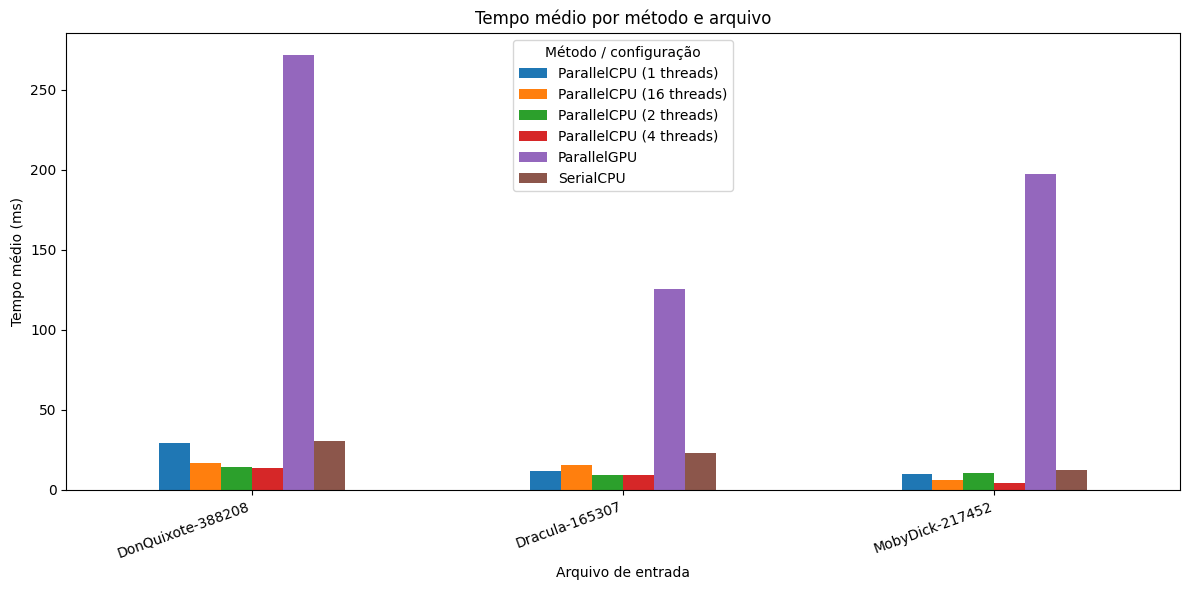

In [3]:
# Gráfico 1: Tempo médio por método e arquivo
graf1 = resumo.copy()
graf1['configuracao'] = graf1.apply(
    lambda r: f"ParallelCPU ({r['threads']} threads)" if r['metodo'] == 'ParallelCPU' else r['metodo'],
    axis=1
)

pivot1 = graf1.pivot_table(
    index='arquivo_curto',
    columns='configuracao',
    values='media_ms',
    aggfunc='mean'
)

ax = pivot1.plot(kind='bar', figsize=(12, 6))
ax.set_title('Tempo médio por método e arquivo')
ax.set_xlabel('Arquivo de entrada')
ax.set_ylabel('Tempo médio (ms)')
ax.legend(title='Método / configuração')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(IMAGES / 'grafico_tempo_medio_por_metodo_e_arquivo.png', dpi=150)
plt.show()


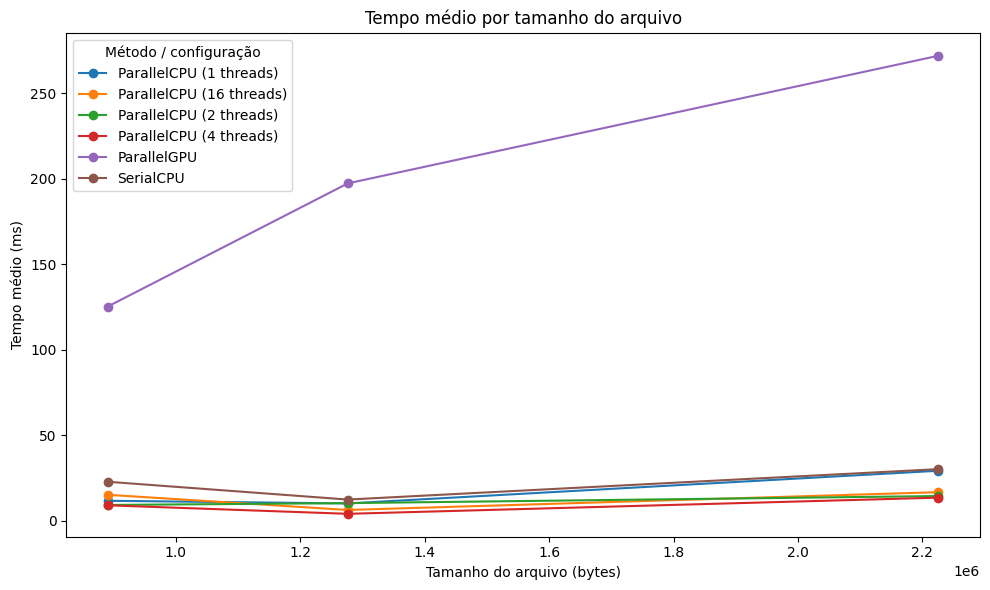

In [4]:
# Gráfico 2: Tempo médio por tamanho do arquivo
graf2 = resumo.copy()
graf2['configuracao'] = graf2.apply(
    lambda r: f"ParallelCPU ({r['threads']} threads)" if r['metodo'] == 'ParallelCPU' else r['metodo'],
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))

for config, dados in graf2.groupby('configuracao'):
    dados = dados.sort_values('tamanho_bytes')
    ax.plot(dados['tamanho_bytes'], dados['media_ms'], marker='o', label=config)

ax.set_title('Tempo médio por tamanho do arquivo')
ax.set_xlabel('Tamanho do arquivo (bytes)')
ax.set_ylabel('Tempo médio (ms)')
ax.legend(title='Método / configuração')
plt.tight_layout()
plt.savefig(IMAGES / 'grafico_tempo_por_tamanho_arquivo.png', dpi=150)
plt.show()


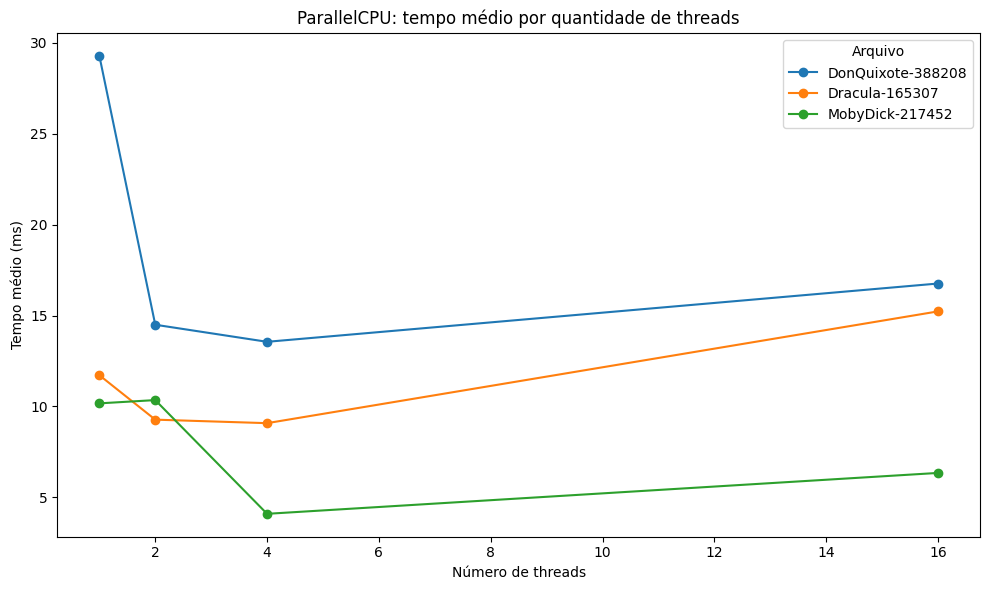

In [5]:
# Gráfico 3: ParallelCPU por número de threads
cpu = resumo[resumo['metodo'] == 'ParallelCPU'].copy()

if cpu.empty:
    print('Não há dados de ParallelCPU para gerar este gráfico.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    for arquivo, dados in cpu.groupby('arquivo_curto'):
        dados = dados.sort_values('threads')
        ax.plot(dados['threads'], dados['media_ms'], marker='o', label=arquivo)

    ax.set_title('ParallelCPU: tempo médio por quantidade de threads')
    ax.set_xlabel('Número de threads')
    ax.set_ylabel('Tempo médio (ms)')
    ax.legend(title='Arquivo')
    plt.tight_layout()
    plt.savefig(IMAGES / 'grafico_parallelcpu_threads.png', dpi=150)
    plt.show()


Linhas do speedup: 15


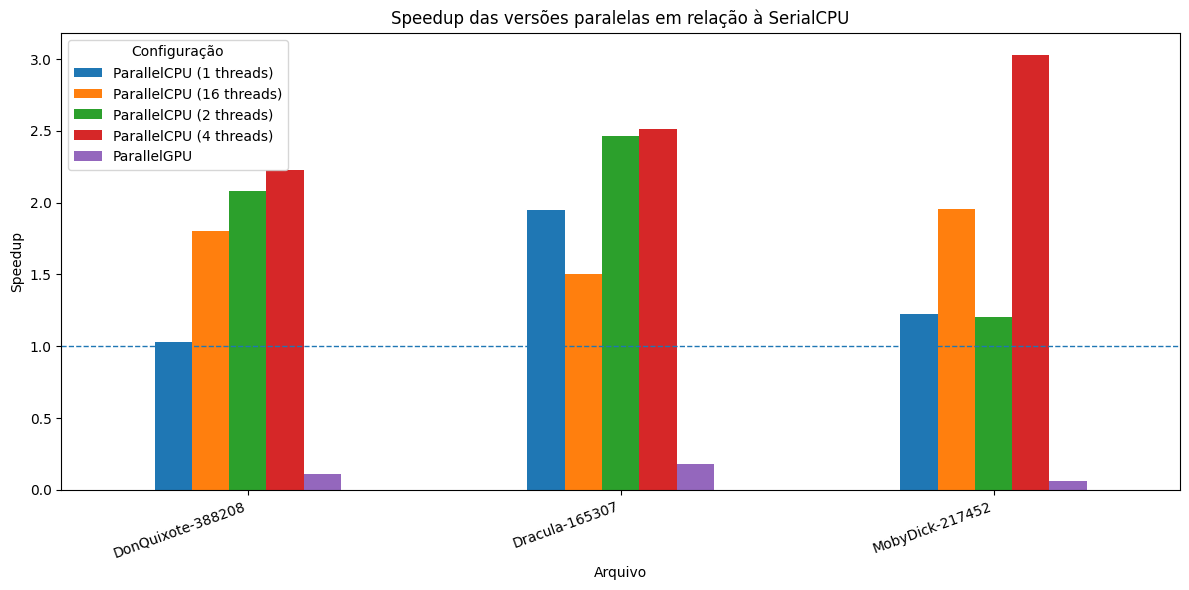

In [6]:
# Gráfico 4: Speedup das versões paralelas em relação à SerialCPU
serial = (
    resumo[resumo['metodo'] == 'SerialCPU'][['arquivo', 'media_ms']]
    .rename(columns={'media_ms': 'serial_ms'})
)

speedup = resumo[resumo['metodo'].isin(['ParallelCPU', 'ParallelGPU'])].merge(serial, on='arquivo', how='inner')
speedup['speedup'] = speedup['serial_ms'] / speedup['media_ms']

speedup['configuracao'] = speedup.apply(
    lambda r: f"ParallelCPU ({r['threads']} threads)" if r['metodo'] == 'ParallelCPU' else 'ParallelGPU',
    axis=1
)

speedup.to_csv(RESULTS / 'speedup.csv', index=False)

print('Linhas do speedup:', len(speedup))

if speedup.empty:
    print('Não há dados paralelos para gerar o gráfico de speedup.')
else:
    pivot_speedup = speedup.pivot_table(
        index='arquivo_curto',
        columns='configuracao',
        values='speedup',
        aggfunc='mean'
    )

    ax = pivot_speedup.plot(kind='bar', figsize=(12, 6))
    ax.axhline(1, linestyle='--', linewidth=1)
    ax.set_title('Speedup das versões paralelas em relação à SerialCPU')
    ax.set_xlabel('Arquivo')
    ax.set_ylabel('Speedup')
    ax.legend(title='Configuração')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(IMAGES / 'grafico_speedup.png', dpi=150)
    plt.show()


In [7]:
print('PNGs gerados em:', IMAGES.resolve())
for img in sorted(IMAGES.glob('*.png')):
    print('-', img.name)

print('\nCSVs gerados em:', RESULTS.resolve())
for csv in sorted(RESULTS.glob('*.csv')):
    print('-', csv.name)


PNGs gerados em: /home/janylson/Downloads/java-parallel-wordcount-benchmark/images
- grafico_parallelcpu_threads.png
- grafico_speedup.png
- grafico_tempo_medio_por_metodo_e_arquivo.png
- grafico_tempo_por_tamanho_arquivo.png

CSVs gerados em: /home/janylson/Downloads/java-parallel-wordcount-benchmark/results
- resultados.csv
- resumo_estatistico.csv
- speedup.csv
